In [47]:
import pandas as pd 
import numpy as np
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

from wordcloud import WordCloud
from nltk.corpus import stopwords

import matplotlib.pyplot as plt 

nltk.download('vader_lexicon')
nltk.download('stopwords')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\CambeddaAndrea\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\CambeddaAndrea\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [33]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
path = "C:\\Users\\CambeddaAndrea\\Downloads\\ArmaniHotelReviews.csv"

df_trip= pd.read_csv(path)



mesi= [mese[0] for mese in df_trip['date_of_stay'].str.split(" ")]
anni= [mese[1] for mese in df_trip['date_of_stay'].str.split(" ")]

df_trip['month']= mesi
df_trip['year']= anni

df_trip.drop("date_of_stay", axis=1, inplace=True)

In [11]:
df_trip

,review_id,review_rating,review_title,review_text,month,year
0,869387650,5.0,I love this hotel,It is truly difficult to find a flaw in this h...,November,2022
1,889405632,5.0,Outstanding time at Armani in Milan,Fantastic experience at the Armani Hotel in Mi...,May,2023
2,779338587,5.0,Great Milano Hotel - Very Well Located,This hotel is all you expect from Armani. Desi...,October,2020
3,837733277,5.0,Thank you Lifestyle team,This hotel deserves a lot more than the flak r...,May,2022
4,923971481,5.0,Stylish Armani in stylish Milan,What an amazing stay! Totally stylish and such...,October,2023
...,...,...,...,...,...,...
735,935509564,5.0,Luxury and comfort,Staying at the Armani hotel was a wish and tha...,December,2023
736,932871072,5.0,Style in the heart of Milan,A dream!All perfectly cared for in Armani styl...,November,2023
737,922309061,4.0,A STUNNING HOTEL BUT,"Excellent bed, expensive but excellent room se...",October,2023
738,918861770,5.0,Beautiful overnight stay in Milan.,"Elegant hotel, both the room and the restauran...",August,2023


In [25]:
sia = SentimentIntensityAnalyzer()

def reviewer(compound):
    if compound <= -0.4:
        return "negativa"
    elif compound <= -0.8:
        return "poco negativa"
    elif compound <= 0.2:
        return "neutra"
    elif compound <= 6:
        return "buona"
    else:
        return "ottima"


df_trip['sentiment_score'] = df_trip['review_text'].astype(str).apply(
    lambda t: sia.polarity_scores(t)['compound']
)

df_trip['compound']=df_trip['sentiment_score'].apply(lambda c :reviewer(c))

df_trip['compound'].unique()

df_trip['reliability_score'] = (df_trip["review_rating"] + df_trip["sentiment_score"])/2
df_trip.drop("reliability score",axis=1,inplace=True)

In [54]:
bad_reviews=df_trip[(df_trip['reliability_score']< 2.5) 
        &
        (df_trip["review_rating"]>=4)
        &
        (df_trip["sentiment_score"]<=0)
        ].sort_values(by="reliability_score",ascending=True)


bad_reviews.shape

(8, 9)

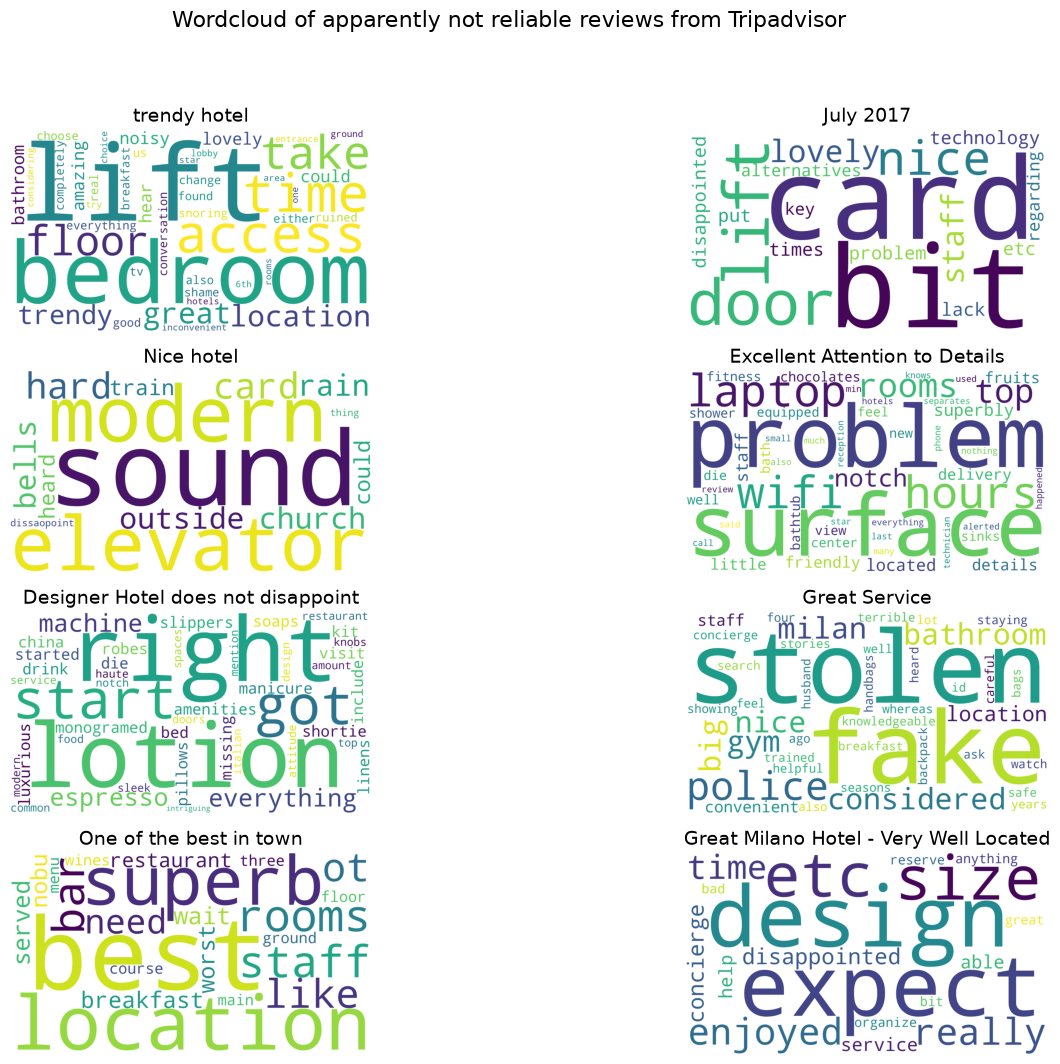

In [92]:
def wordcloud_charts(dataframe, text_column :str, title:str):
    stop= set(stopwords.words("english"))
    stop.update(['hotel', 'room', 'stay', 'would', 'get',"use","armani","thought",'maybe',"another","next","however"]) 

    texts= dataframe[text_column]
    titles= dataframe[title]

    rows, columns = dataframe.shape
    fig, ax = plt.subplots(rows//2,2,figsize=(16,12))
    
    plt.suptitle("Wordcloud of apparently not reliable reviews from Tripadvisor",fontsize=16)
    r,c= 0,0
    for i in range(rows):
        c= i % 2
        r = i//2

        wc = WordCloud(
        width=1800, height=1000,
        background_color='white',
        stopwords=stop,          # WordCloud accetta direttamente un set di stopword
        max_words=50,
        ).generate(texts.iloc[i].lower())

       
        ax[r,c].imshow(wc)
        ax[r,c].axis("off")


        ax[r,c].set_title(titles.iloc[i],fontsize= 14)
        
wordcloud_charts(bad_reviews,"review_text", "review_title")
        
